# Monte Carlo BB light curve study

In [1]:
%reset -f
# Load the autoreload extension and automatically reload all modules before executing code
%load_ext autoreload 
%autoreload 2 
%run setup_notebook.py
%run pylib/setup dark
from pylib import data_setup
from importlib import reload
from pylib import mc_dev; reload(mc_dev)
from pylib.mc_dev import (sim_design_thoughts, check_step, BBsim, p_view, show, show_date, show_fig,
                          capture_hide, plt, sns, pd, np)
from wtlike import WtLike, Timer
show_date()

<h5 style="text-align:right; margin-right:15px"> 2026-08-11 10:26</h5>

In [2]:
# show(sim_design_thoughts, summary='Simulation design')
name = '4FGL J0056.3-0935' # strong single-step
show(f"""Choose {name} to use for MC study""")
with capture_hide(f'Source setup output for {name}') as printout:
    wtl = WtLike(name, time_bins=(0,0,30),clear=False)
show(printout)
show(f'Will use its `{len(wtl.photons)}` weight values for simulation') 

Choose 4FGL J0056.3-0935 to use for MC study

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x781c227aeba0>

Will use its `85266` weight values for simulation

## BB with data

Bayesian Blocks: partitioning 218  cells using LikelihoodFitness with penalty 5%
	found 2 / 218 blocks.
LightCurve: Loaded 2 / 2 cells for fitting


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x781c21e2ae40>
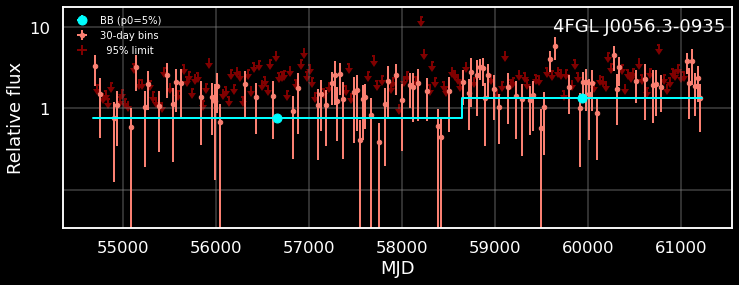

TSvar = 24.8 for 2 blocks

Single step observed at MJD 58643.0, 
ratio 1.75

In [3]:
show(f"""## BB with data""")
bb_full = wtl.bb_view()
bb_full.plot(log=True);
show(plt.gcf())

step = check_step(bb_full)
# bb_full_r = wtl.bb_view(reverse=True)
# check_step(bb_full_r)

# Create partitions 

LightCurve: Loaded 102 / 102 cells for fitting
Bayesian Blocks: partitioning 102 reversed cells using LikelihoodFitness with penalty 5%
	found 2 / 102 blocks.
LightCurve: Loaded 2 / 2 cells for fitting


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x781c227afcb0>
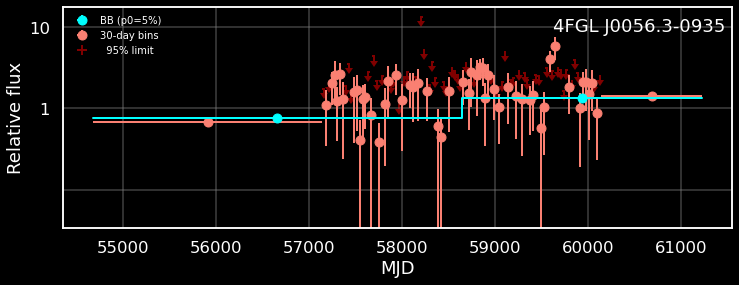

TSvar = 24.8 for 2 blocks

Single step observed at MJD 58643.0, 
ratio 1.75

### Set partition to expand times [57143.0, 60143.0]

In [4]:
show(f"""# Create partitions """)
delta = 1500
trange=[step.time-delta,step.time+delta]
partition_view = p_view(wtl, *trange)# pedges)
bbv = partition_view.bb_view(reverse=True)
bbv.plot(log=True)#, xlim=(56900,57500)); 
show(plt.gcf())

step = check_step(bbv)
show(f"""### Set partition to expand times {trange}""")
first = partition_view.cells.iloc[0]
last  = partition_view.cells.iloc[-1]
full = pd.Series(wtl.concatenate())

# Run BBsim

In [5]:
reload (mc_dev); from pylib.mc_dev import BBsim
show_date()
show(f"""### Run the simulation {(N:=10000) } times on {(nproc:=8)} processors. """)
bbs, df_all = BBsim.run_many(partition_view,  seeds=range(N), nproc=nproc,
                             step_time=step.time,#+15,
                             cache='files/bbsim/cache_00.pkl')
# show(et)
df_all.head()

<h5 style="text-align:right; margin-right:15px"> 2026-08-11 10:27</h5>

### Run the simulation 10000 times on 8 processors. 

### Setup BB fit sims with cell partitioning
Assume step at 58643.0 

* Loading cached results from `files/bbsim/cache_00.pkl`, last modified: 2026-07-22 14:30:26

,time,ts,ratio,nbb,gap
0,58313.0,44.2,2.10,2,0.0
1,58643.0,46.3,2.15,2,0.0
2,58493.0,60.9,2.45,2,0.0
3,58673.0,54.1,2.33,2,0.0
4,58958.0,67.5,2.21,4,570.0


## Plots of the results

Number of blocks <br>
         

,2,3,4
instances,9735,214,51


Selecting nbb==2

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x781c222452b0>
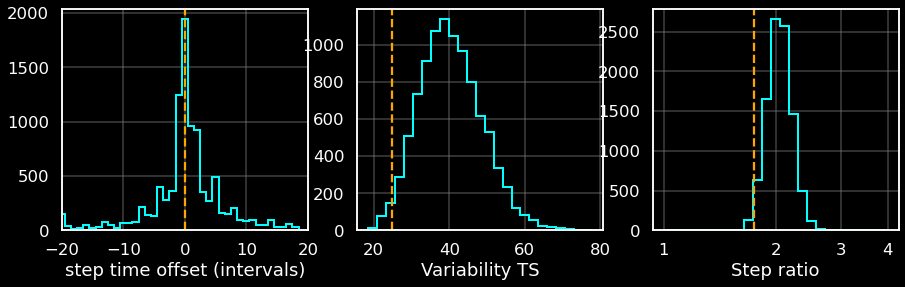

In [6]:
reload (mc_dev); from pylib.mc_dev import BBsim_plots
simplots = BBsim_plots(bbs, df_all, step, interval=40)
simplots.hists(dtmax=20)

Selecting nbb>2

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x781c222452b0>
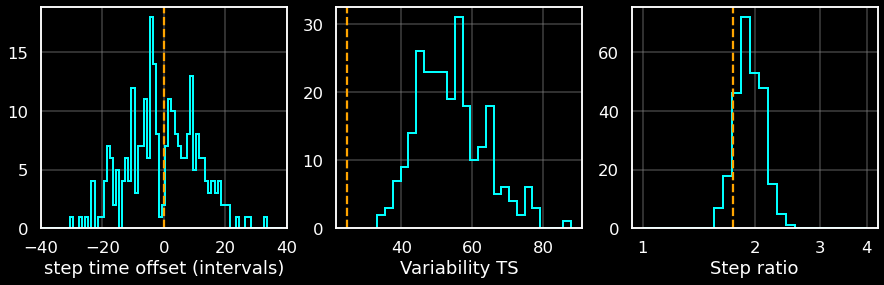

In [7]:
simplots.hists('nbb>2')

### Corner pairplot

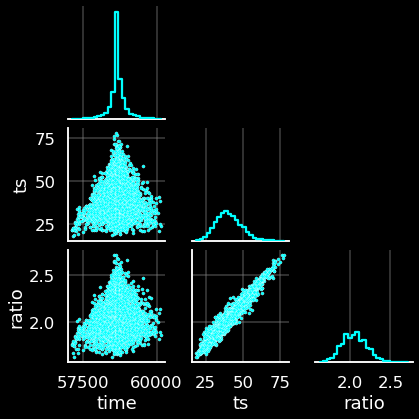

In [8]:
show('### Corner pairplot')
df2 = df_all.query('nbb==2')
sns.pairplot(df2.drop(['nbb','gap'],axis=1), height=2,corner=True,
             diag_kws=dict(bins=25, element='step',fill=False, color='cyan'),
             plot_kws=dict(s=10, color='cyan'),
        );

In [9]:
from wtlike.lightcurve import flux_plot
def simulate_and_plot(seed, trange, step, ax=None, **kwargs):
    with capture_hide():
        bv =bbs.sim_view(step_time=None, seed=seed).bb_view()
        # y = list(bv.fits.fit.apply(lambda fit: fit.flux)) # flux values from the fits

    #ax.axvspan(*trange,  color='0.2')
    _, ax = plt.subplots(figsize=(12, 6)) if ax is None else (None, ax)
    flux_plot(bv.fits, ax=ax, source_name=f'seed {seed}',
            colors='cyan none none'.split(), log=False);
    ax.get_legend().remove()
    ax.axvline(step.time, color='orange',ls='--')   
    ax.set(xlim=(trange ), xlabel='', ylabel='', **kwargs)# ylim=(y[0], y[-1]))

### Examine the first 20 of the 214 nbb==3 cases 

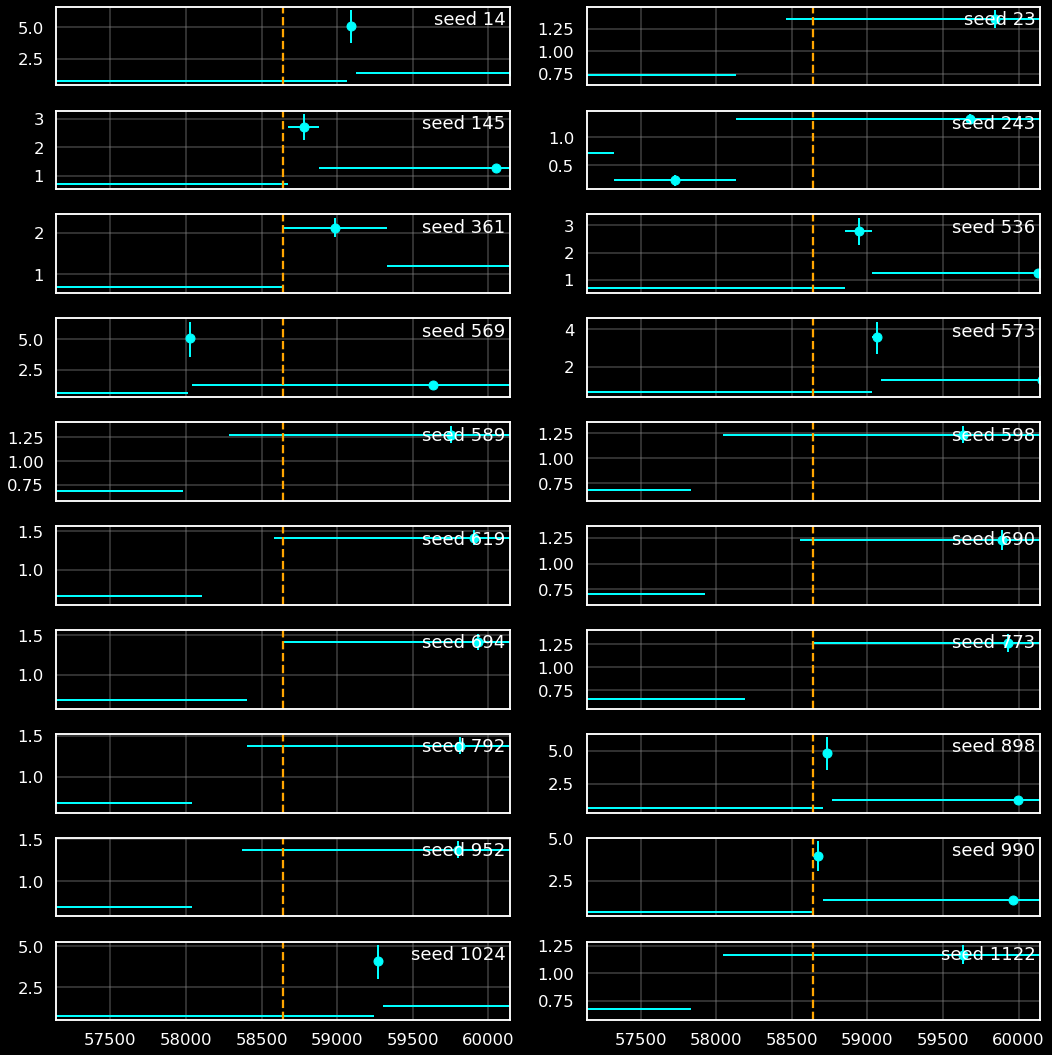

In [10]:
nrows, ncols = 10, 2
show(f"""### Examine the first {nrows*ncols} of the {len(df_all.query('nbb==3'))} nbb==3 cases """)

fig, axx = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15,15),sharex=True)#,sharey=True)
for seed, ax in zip(df_all.query('nbb==3').index[:nrows*ncols], axx.flat):
    with capture_hide():
        simulate_and_plot(seed, trange, step, ax=ax)
plt.tight_layout()
plt.show()

### Plot all details for a few 3-block cases with one a limit 

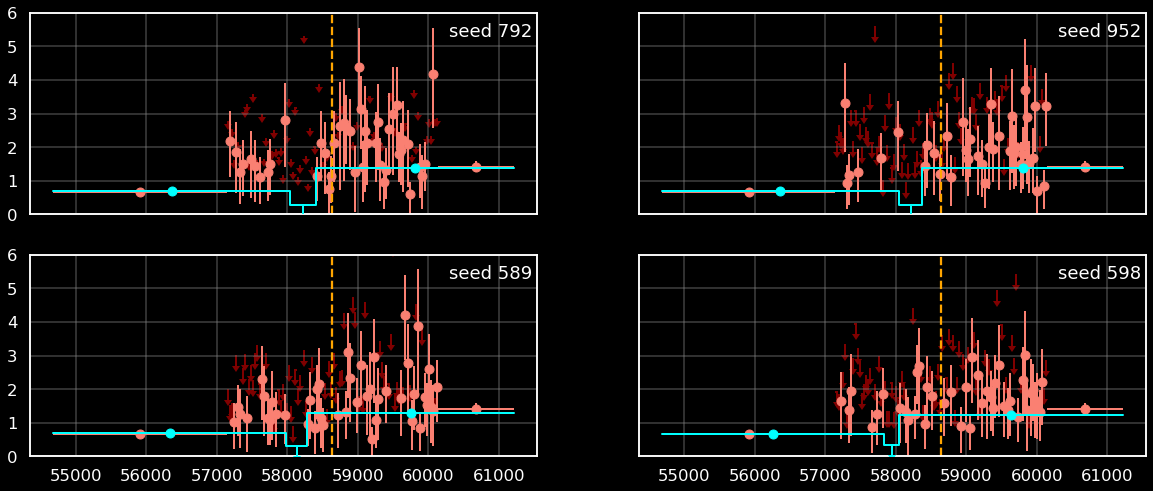

In [11]:
show("""### Plot all details for a few 3-block cases with one a limit """)
fig, axx = plt.subplots(nrows=2, ncols=2, figsize=(20, 8), sharex=True, sharey=True)
for seed, ax in zip([792, 952, 589, 598], axx.flat):
    # show(f""" check details of seed {(seed:=792)} """)
    # simulate_and_plot(seed, trange=(None, None), step=step, ylim=(0,None))
    with capture_hide():
        bv =bbs.sim_view(step_time=None, seed=seed).bb_view()
    
    y = list(bv.fits.fit.apply(lambda fit: fit.flux)) 
    # fig, ax = plt.subplots(figsize=(12, 4))
    bv.plot(source_name=f'seed {seed}', ax=ax)
    ax.set(xlabel='', ylabel='', ylim=(0,6))
    ax.axvline(step.time, color='orange',ls='--')   
    ax.get_legend().remove();
plt.show()

### Examine first 10 of the 51 nbb==4 cases 

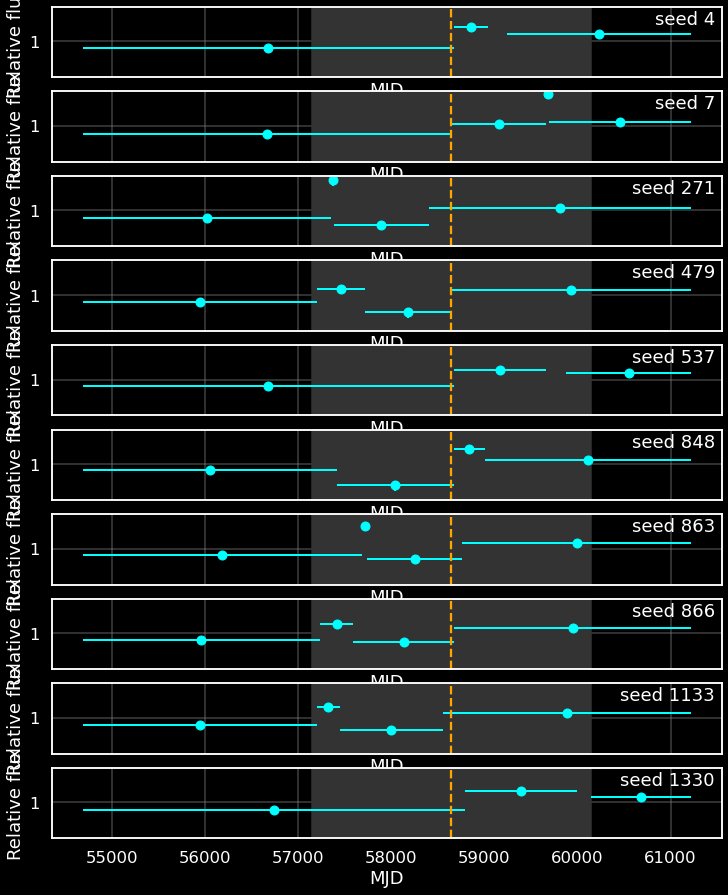

In [12]:
show(f"""### Examine first 10 of the {len(df_all.query('nbb==4'))} nbb==4 cases """)
from wtlike.lightcurve import flux_plot
fig, axx = plt.subplots(nrows=10, figsize=(12,15),sharex=True,sharey=True)
for seed, ax in zip(df_all.query('nbb==4').index, axx.flat):
    with capture_hide():
        bv =bbs.sim_view(step_time=None, seed=seed).bb_view()

    ax.axvspan(*trange,  color='0.2')
    flux_plot(bv.fits, ax=ax, source_name=f'seed {seed}',
              colors='cyan none none'.split(),log=True);
    ax.get_legend().remove()
    ax.axvline(step.time, color='orange',ls='--')


---
# Tests and demos

## Demonstrate `CellSim` weight generation

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x781c222456a0>
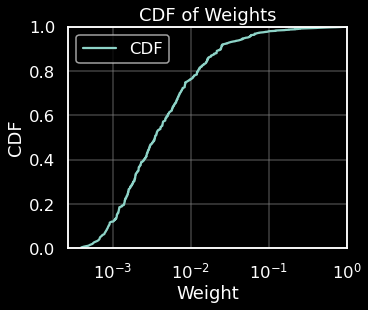

| Sample  | N | $<w>$ | $<w^2>$ | $\alpha$ | $\sigma_\alpha$
| --------|--:|------:|--------:|---------:|-----------
|data     | 85,027|1.50e-02| 3.79e-03|-0.003 | 0.056
|uniform  | 85,027|1.50e-02| 3.79e-03|-0.003 | 0.056
|random   | 85,027|1.49e-02| 3.73e-03|-0.030 | 0.056

In [13]:
from pylib.mc_dev import CellSim
show(f"""## Demonstrate `CellSim` weight generation""")
show(CellSim.plot_cdf(full))
show(CellSim.check_weights(full)     )  
        

## Select a cell for sampling
Use CellSim to generate 100 trials

The sammple:
 t                                               59933.0
tw                                               2580.0
e                                           1516.311768
n                                                 34291
S                                            505.969811
B                                             33142.143
w     [0.005695343, 0.002275467, 0.006298065, 0.0008...
Name: 1, dtype: object


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x781c222456a0>
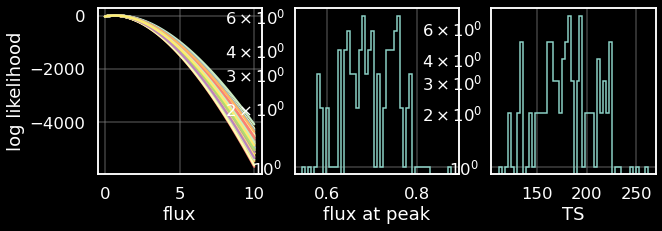

## Combine 100 simulated likelihoods
1. Using table lookup scheme with 1000 points.<br>
This is what is done by the BB algorithm.
2. Combine the cells

CPU times: user 82.6 ms, sys: 474 μs, total: 83.1 ms
Wall time: 84.4 ms


0.695[1+0.011-0.011], < 0.71

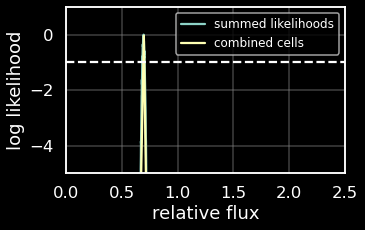

In [14]:

show(f"""## Select a cell for sampling
Use CellSim to generate {(N:=100)} trials""")
from wtlike.loglike import LogLike, PoissonRep
sample_cell = bb_full.cells.iloc[1]
print('The sammple:\n',sample_cell)
csim = CellSim(first)
trial_cells = pd.DataFrame([csim(sample_cell) for i in range(N)])

pp = [PoissonRep(LogLike(csim(trial_cells.iloc[i]))) for i in range(N)]

fig, (ax3,ax1,ax2) = plt.subplots(ncols=3, figsize=(10,3))
ax1.hist([x.flux for x in pp], bins=50, histtype='step')
ax1.set(xlabel='flux at peak',yscale='log')
ax2.hist([x.ts for x in pp], bins=50, histtype='step')
ax2.set(xlabel='TS',yscale='log')


x = np.linspace(0,10,100);
for f in pp[:100]:
    ax3.plot(x, f(x));
ax3.set(xlabel='flux',ylabel='log likelihood');
show(fig)


show(f"""## Combine {len(pp)} simulated likelihoods
1. Using table lookup scheme with {(npt:=1000)} points.<br>
This is what is done by the BB algorithm.
2. Combine the cells""")
R=len(pp)-1
%time tables = list(map(lambda p: p.create_table(npt), pp))
a, y = tables[R]
x = np.linspace(*a)
y = np.zeros(npt)
rv = np.empty(R+1)
for i in range(R,-1,-1):
    a, yi = tables[i]
    xi = np.linspace(*a)
    y += np.interp(x, xi, yi, left=-np.inf, right=-np.inf)
    amax = np.argmax(y)
    rv[i] = y[amax]

plt.plot(x,y-np.max(y), label='summed likelihoods'); 

def concat(pcells,):
    newcell = dict()
    for col in 'n S B'.split():
        newcell[col] = pcells[col].sum()
    newcell['w'] = np.concatenate(pcells.w.values)
    return newcell
pr = PoissonRep(LogLike(concat(trial_cells)))
show(str(pr))
plt.plot((x:=np.linspace(0,3,100)), pr(x), label='combined cells');
plt.gca().set(xlim=(0.,2.5), ylim = (-5,1), ylabel='log likelihood', xlabel='relative flux');
plt.axhline(-1, ls='--')
plt.legend(fontsize=12); plt.show()

In [15]:
show(f"""## Simulate the large cells, to check errors
    With {(N:=4000)} trials each.""")
cells = (first, last, full)
from multiprocessing import Pool

def run_sim(i):
    cell = cells[i]
    return  np.array([PoissonRep(LogLike(CellSim(cell)(cell,inplace=False))).flux for k in range(N)])

with Timer() as et:
    with Pool(len(cells)) as pool:
        fluxes = pool.map(run_sim, range(len(cells)))
show(et)

## Simulate the large cells, to check errors
With 4000 trials each.

elapsed time: 48.4s (0.8 min)

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x781c22247380>
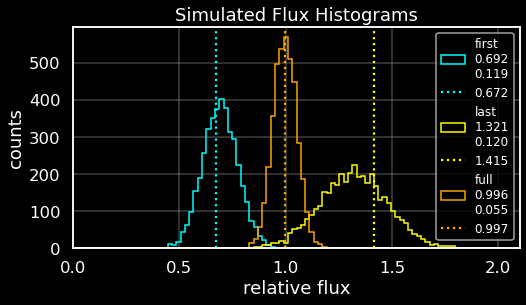

In [16]:
def plot_flux_histograms():
    """For a source with two blocks, plot histograms of the simulated fluxes 
    for the first, last, and full, or combined cells. 
    The legend shows the mean and relative standard deviation of each histogram, 
    with the generated flux indicated by a vertical dotted line.
    """

    hkw = dict(bins=np.linspace(0,2,100), histtype='step')
    fig, ax = plt.subplots(figsize=(8,4))
    for fx, color, cell, name in zip( fluxes, 'cyan yellow orange'.split(), cells, 'first last full'.split()):
        ax.hist(fx,**hkw, label=f"{name}\n{fx.mean():.3f}\n{fx.std()/fx.mean():.3f}", color=color);
        ax.axvline((genf:=CellSim(cell).flux), ls=':', color=color, label=f'{genf:.3f}')

    ax.legend(fontsize=12)
    ax.set(xlabel='relative flux', ylabel='counts', title='Simulated Flux Histograms', 
           xticks=np.arange(0,2.1,0.5),xlim=(0,None))
    return fig

show_fig(plot_flux_histograms, fignum=1)

In [17]:
from wtlike import check_data
check_data(update=False)
# show_date()

Weekly folder "/mnt/c/Users/thbur/onedrive/fermi/wtlike-data/data_files" contains 938 weeks.
	 Last week in local dataset, #947, has 1.740 days, ends at UTC 2026-07-24 18:45, filedate 20260724211459
Weeks needing download: [947, 948, 949]


In [27]:
from utilities import export_notebook_to_markdown
export_notebook_to_markdown('notebooks/Monte_Carlo', output_dir='docs')

✅ Export complete: parsed 23 cells, wrote 54 segments to docs/notebooks/Monte_Carlo.md


In [26]:
from pathlib import Path
output_dir = Path('docs/notebooks')
list(output_dir.glob('*.md'))

[PosixPath('docs/notebooks/cell_sim.md'),
 PosixPath('docs/notebooks/Monte_Carlo.md')]

'/mnt/c/Users/thbur/onedrive/work/agnsteps'